In [244]:
import os
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD

# Metadata

In [245]:
proj_root = os.environ['PYTHONPATH']
proj_root

'C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1'

## preproc params

In [246]:
# здесь мы определяем критерии перегрузки сети
thres_fld = 'n_flows'
thres_factor = 2.5
post_window = 7
drop_inst_ids_list = [217, 246]

# Соберем целевой TS-датасет (пока двумерный)

## сперва посмотрим на данные

In [247]:
flds_selection = [
    'id_time', 
    'n_flows', 'n_packets', 'n_bytes',
    'std_n_dest_ip', 'std_n_dest_ports',
    'tcp_udp_ratio_packets', 'dir_ratio_packets',
    'avg_duration', 'avg_ttl'
]

In [248]:
pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '0.csv'))[flds_selection]

,id_time,n_flows,n_packets,n_bytes,std_n_dest_ip,std_n_dest_ports,tcp_udp_ratio_packets,dir_ratio_packets,avg_duration,avg_ttl
0,0,17967588,2009822494,1937481519695,96.12,63.32,0.76,0.48,20.75,135.95
1,1,17222782,2063503609,2003213170261,95.48,132.03,0.76,0.49,21.05,135.18
2,2,19697341,2458140183,2431213005090,100.91,154.51,0.76,0.47,21.00,137.09
3,3,19702256,2321789135,2273312421852,99.45,139.36,0.76,0.48,20.70,136.28
4,4,17396165,2059123443,2007808467610,86.80,134.48,0.77,0.45,17.70,149.85
...,...,...,...,...,...,...,...,...,...,...
275,275,10660088,1183226129,1156169960010,66.47,59.81,0.74,0.47,22.76,129.99
276,276,11555928,1020931320,974118051467,76.87,176.64,0.74,0.48,22.86,134.34
277,277,11042880,1008125606,964115099922,66.38,88.52,0.74,0.46,21.97,130.42
278,278,9182379,1108790324,1134577908505,57.64,52.35,0.75,0.46,20.80,131.26


## выбор порога нетривиален - с одной стороны, в среднем по всем институтам это должно быть нечастое явление, но для целевого института дать хотя бы 20% случаев - чтобы было на чем обучаться модели! 

In [249]:
top_3 = []

for tmp_thres_factor in [1.5, 2, 2.5, 3, 3.5, 4, 5, 7, 10]:
    overloaded_list = []

    for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

        tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

        tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * tmp_thres_factor

        overloaded_list.append(tmp_df['is_overloaded'].sum())

    top_3.append([tmp_thres_factor] + sorted(overloaded_list)[-3:] + [round(sum(overloaded_list)/280, 2)])

top_3 = np.array(top_3)
top_3

array([[  1.5 , 100.  , 100.  , 103.  ,  33.76],
       [  2.  ,  58.  ,  66.  ,  77.  ,   7.29],
       [  2.5 ,  36.  ,  53.  ,  53.  ,   2.67],
       [  3.  ,  25.  ,  26.  ,  34.  ,   1.49],
       [  3.5 ,  16.  ,  16.  ,  20.  ,   0.91],
       [  4.  ,  15.  ,  16.  ,  16.  ,   0.59],
       [  5.  ,  11.  ,  14.  ,  15.  ,   0.36],
       [  7.  ,   6.  ,  10.  ,  14.  ,   0.22],
       [ 10.  ,   6.  ,   9.  ,  14.  ,   0.16]])

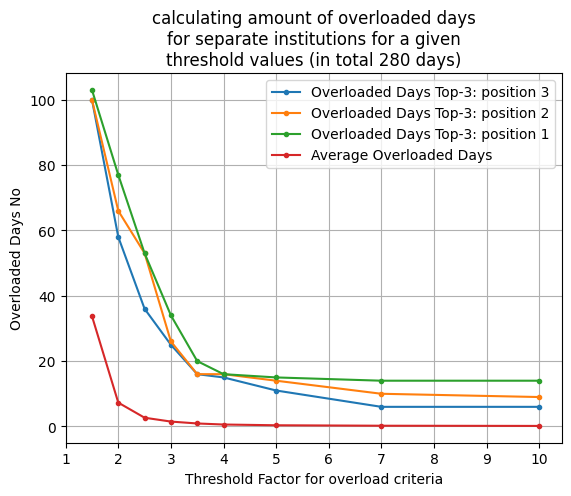

In [250]:
for i in [1,2,3]:
    plt.plot(top_3[:,0], top_3[:,i], label=f'Overloaded Days Top-3: position {4-i}', marker='.')

plt.plot(top_3[:,0], top_3[:,4], label='Average Overloaded Days', marker='.')
plt.title('calculating amount of overloaded days\n' +
          'for separate institutions for a given\n' + 
          'threshold values (in total 280 days)')
plt.xlabel('Threshold Factor for overload criteria')
plt.ylabel('Overloaded Days No')
plt.legend()
plt.xticks(range(1,11))
plt.grid()
plt.show()

In [251]:
for csv_file in [el for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) if el.endswith('.csv')]:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', csv_file))[flds_selection]

    tmp_df['is_overloaded'] = tmp_df[thres_fld] > tmp_df[thres_fld].mean() * thres_factor

    if tmp_df['is_overloaded'].sum() > 30:
        print(f"File {csv_file} has {tmp_df['is_overloaded'].sum()} overloaded days")

File 217.csv has 53 overloaded days
File 246.csv has 36 overloaded days
File 264.csv has 53 overloaded days


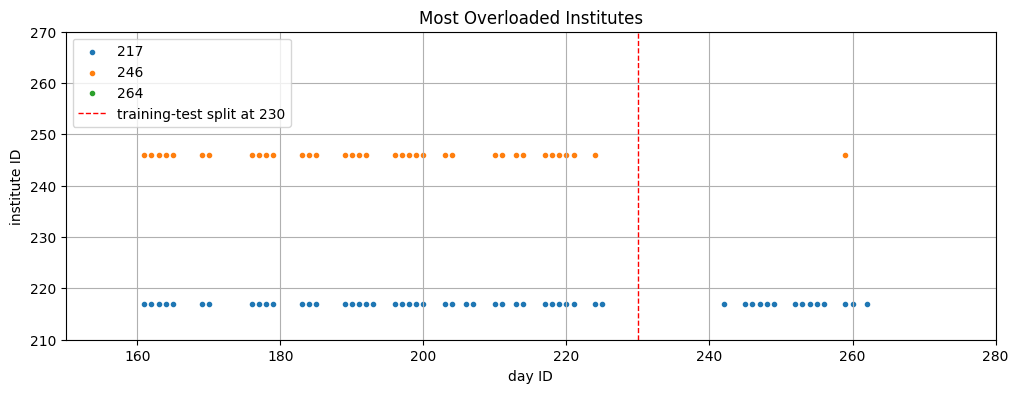

In [252]:
tmp_df_217 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '217.csv'))[flds_selection]
tmp_df_217['is_overloaded'] = tmp_df_217[thres_fld] > tmp_df_217[thres_fld].mean() * thres_factor

tmp_df_246 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '246.csv'))[flds_selection]
tmp_df_246['is_overloaded'] = tmp_df_246[thres_fld] > tmp_df_246[thres_fld].mean() * thres_factor

tmp_df_264 = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', '264.csv'))[flds_selection]
tmp_df_264['is_overloaded'] = tmp_df_264[thres_fld] > tmp_df_264[thres_fld].mean() * thres_factor

plt.figure(figsize=(12, 4))

plt.scatter(tmp_df_217.id_time, 217*tmp_df_217['is_overloaded'], label='217', marker='.')
plt.scatter(tmp_df_246.id_time, 246*tmp_df_246['is_overloaded'], label='246', marker='.')
plt.scatter(tmp_df_264.id_time, 264*tmp_df_264['is_overloaded'], label='264', marker='.')
plt.axvline(230, color='red', linestyle='--', linewidth=1, label='training-test split at 230')
plt.ylim(210, 270)
plt.xlim(150,280)  #(150, 280)
plt.xlabel('day ID')
plt.ylabel('institute ID')
plt.title('Most Overloaded Institutes')
plt.legend(loc='upper left')
plt.grid()
plt.show()

## итак мы выбрали 217 институт - сохраним разметку по нему

In [253]:
print('\nПри пороговом множителе роста нагрузки по сравнению со средней на уровне', thres_factor,
      'целевая разметка будет:')
tmp_df_217['is_overloaded'].map(int).value_counts()


При пороговом множителе роста нагрузки по сравнению со средней на уровне 2.5 целевая разметка будет:


is_overloaded
0    227
1     53
Name: count, dtype: int64

In [254]:
tmp_df_217[['id_time','is_overloaded']].map(int).to_csv(
          os.path.join(proj_root, 'preprocessed_datasets', 'inst_217_marked_target.csv'), index=False)

## поехали собирать весь датасет

In [255]:
inst_ids_list = sorted([ int(el.split('.')[0]) 
                         for el in os.listdir(os.path.join(proj_root,'data','institutions','agg_1_day')) 
                         if el.endswith('.csv') ])

inst_ids_list = [el for el in inst_ids_list if el not in drop_inst_ids_list]


In [256]:
predictors_df = pd.read_csv(os.path.join(proj_root,'preprocessed_datasets','ts_days_df.csv')).drop(columns=['day']) 

for inst_id in inst_ids_list:

    tmp_df = pd.read_csv(os.path.join(proj_root,'data','institutions','agg_1_day', f'{inst_id}.csv'))[flds_selection]
    
    for col in tmp_df.columns:
        if col != 'id_time':
            tmp_df[col] = tmp_df[col].astype(float)
            
    tmp_df.columns = [el + '_' + str(inst_id) for el in tmp_df.columns]
    tmp_df.rename(columns={'id_time' + '_' + str(inst_id): 'id_time'}, inplace=True)

    predictors_df = predictors_df.merge(tmp_df, on='id_time', how='left')

predictors_df.shape

(280, 2532)

**а сколько должно быть?  у нас 283 института, выкинули два id (217 и 246) - каждый институт тащит 9 фич, плюс три общих (таймстемп, день недели и флаг рабочего дня) - итого, все сошлось:**

In [257]:
(9 * (283-2)) + 3

2532

In [258]:
predictors_df

,id_time,day_of_week,is_working_day,n_flows_0,n_packets_0,n_bytes_0,std_n_dest_ip_0,std_n_dest_ports_0,tcp_udp_ratio_packets_0,dir_ratio_packets_0,...,avg_ttl_283,n_flows_284,n_packets_284,n_bytes_284,std_n_dest_ip_284,std_n_dest_ports_284,tcp_udp_ratio_packets_284,dir_ratio_packets_284,avg_duration_284,avg_ttl_284
0,0,0,1,17967588.0,2.009822e+09,1.937482e+12,96.12,63.32,0.76,0.48,...,175.06,22852.0,29771.0,1115958.0,36.05,2.05,0.46,0.47,3.43,207.42
1,1,1,1,17222782.0,2.063504e+09,2.003213e+12,95.48,132.03,0.76,0.49,...,171.19,21166.0,28199.0,1061740.0,33.25,1.78,0.45,0.47,3.57,210.09
2,2,2,1,19697341.0,2.458140e+09,2.431213e+12,100.91,154.51,0.76,0.47,...,168.78,25781.0,34359.0,1294795.0,40.28,2.07,0.47,0.45,3.53,210.00
3,3,3,1,19702256.0,2.321789e+09,2.273312e+12,99.45,139.36,0.76,0.48,...,177.36,25467.0,33715.0,1259480.0,39.80,1.91,0.43,0.45,3.55,208.37
4,4,4,1,17396165.0,2.059123e+09,2.007808e+12,86.80,134.48,0.77,0.45,...,183.41,26797.0,35387.0,1324206.0,39.66,2.04,0.44,0.43,3.60,208.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2,1,10660088.0,1.183226e+09,1.156170e+12,66.47,59.81,0.74,0.47,...,NaN,2604.0,7289.0,480445.0,6.19,1.40,0.57,0.46,18.43,198.62
276,276,3,1,11555928.0,1.020931e+09,9.741181e+11,76.87,176.64,0.74,0.48,...,NaN,2399.0,6121.0,384697.0,4.77,1.57,0.62,0.45,20.67,211.74
277,277,4,1,11042880.0,1.008126e+09,9.641151e+11,66.38,88.52,0.74,0.46,...,NaN,2651.0,7664.0,503624.0,5.45,1.50,0.59,0.46,23.76,205.29
278,278,5,0,9182379.0,1.108790e+09,1.134578e+12,57.64,52.35,0.75,0.46,...,NaN,2728.0,7849.0,511897.0,6.13,1.65,0.59,0.47,22.67,203.34


### заполняем пропуски средними значениями

In [259]:
print('\nFYI: Number of missing values:', predictors_df.isna().values.sum(), 
      'versus', predictors_df.notna().values.sum(), 'of not missing ones\n')


FYI: Number of missing values: 5157 versus 703803 of not missing ones



In [260]:
predictors_df = predictors_df.fillna(predictors_df.mean(), inplace=True)

print('\nFYI: Number of missing values:', predictors_df.isna().values.sum(), 
      'versus', predictors_df.notna().values.sum(), 'of not missing ones\n')


FYI: Number of missing values: 0 versus 708960 of not missing ones



In [261]:
predictors_df

,id_time,day_of_week,is_working_day,n_flows_0,n_packets_0,n_bytes_0,std_n_dest_ip_0,std_n_dest_ports_0,tcp_udp_ratio_packets_0,dir_ratio_packets_0,...,avg_ttl_283,n_flows_284,n_packets_284,n_bytes_284,std_n_dest_ip_284,std_n_dest_ports_284,tcp_udp_ratio_packets_284,dir_ratio_packets_284,avg_duration_284,avg_ttl_284
0,0,0,1,17967588.0,2.009822e+09,1.937482e+12,96.12,63.32,0.76,0.48,...,175.060000,22852.0,29771.0,1115958.0,36.05,2.05,0.46,0.47,3.43,207.42
1,1,1,1,17222782.0,2.063504e+09,2.003213e+12,95.48,132.03,0.76,0.49,...,171.190000,21166.0,28199.0,1061740.0,33.25,1.78,0.45,0.47,3.57,210.09
2,2,2,1,19697341.0,2.458140e+09,2.431213e+12,100.91,154.51,0.76,0.47,...,168.780000,25781.0,34359.0,1294795.0,40.28,2.07,0.47,0.45,3.53,210.00
3,3,3,1,19702256.0,2.321789e+09,2.273312e+12,99.45,139.36,0.76,0.48,...,177.360000,25467.0,33715.0,1259480.0,39.80,1.91,0.43,0.45,3.55,208.37
4,4,4,1,17396165.0,2.059123e+09,2.007808e+12,86.80,134.48,0.77,0.45,...,183.410000,26797.0,35387.0,1324206.0,39.66,2.04,0.44,0.43,3.60,208.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
275,275,2,1,10660088.0,1.183226e+09,1.156170e+12,66.47,59.81,0.74,0.47,...,188.910462,2604.0,7289.0,480445.0,6.19,1.40,0.57,0.46,18.43,198.62
276,276,3,1,11555928.0,1.020931e+09,9.741181e+11,76.87,176.64,0.74,0.48,...,188.910462,2399.0,6121.0,384697.0,4.77,1.57,0.62,0.45,20.67,211.74
277,277,4,1,11042880.0,1.008126e+09,9.641151e+11,66.38,88.52,0.74,0.46,...,188.910462,2651.0,7664.0,503624.0,5.45,1.50,0.59,0.46,23.76,205.29
278,278,5,0,9182379.0,1.108790e+09,1.134578e+12,57.64,52.35,0.75,0.46,...,188.910462,2728.0,7849.0,511897.0,6.13,1.65,0.59,0.47,22.67,203.34


### сохраняем до и после нормализации столбцов

In [262]:
predictors_df.to_csv(os.path.join(proj_root, 'preprocessed_datasets', 'predictors_df.csv'), index=False)

In [263]:
scaler = StandardScaler()

predictors_scaled = predictors_df.copy(deep=True)
predictors_scaled.iloc[:,3:] = scaler.fit_transform(predictors_df.iloc[:,3:])

predictors_scaled.to_csv(os.path.join(proj_root, 'preprocessed_datasets', 'predictors_scaled.csv'), index=False) 

joblib.dump(scaler, os.path.join(proj_root, 'py_obj_saves', 'predictors_scaler.joblib'))

['C:\\Users\\aseva\\Desktop\\MyEDU\\OTUS\\ML_Adv\\OTUS_ML_Adv_GradProj_SaintSanych_v1\\py_obj_saves\\predictors_scaler.joblib']

### выбираем транкирование и сохраняем варианты с уменьшением размерности

In [264]:
pca_object = PCA(n_components=250)
X_pca = pca_object.fit_transform(predictors_df.iloc[:,1:])

In [265]:
svd_object = TruncatedSVD(n_components=250)
X_svd = svd_object.fit_transform(predictors_df.iloc[:,1:])

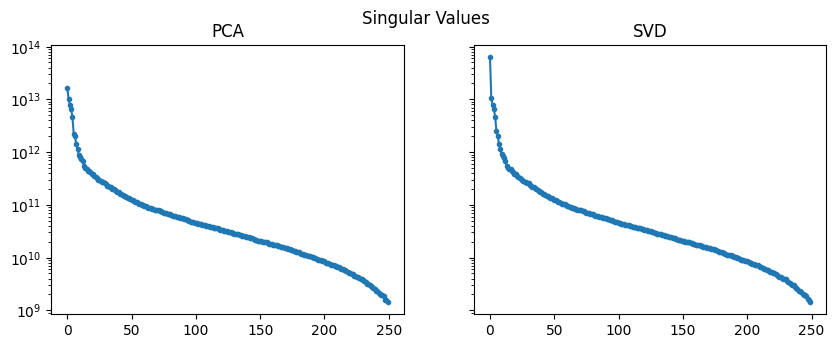

In [266]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

ax1.plot(pca_object.singular_values_, marker='.')
ax1.set_yscale('log')
ax1.set_title('PCA')

ax2.plot(svd_object.singular_values_, marker='.')
ax2.set_yscale('log')
ax2.set_title('SVD')

fig.suptitle('Singular Values')
plt.show()

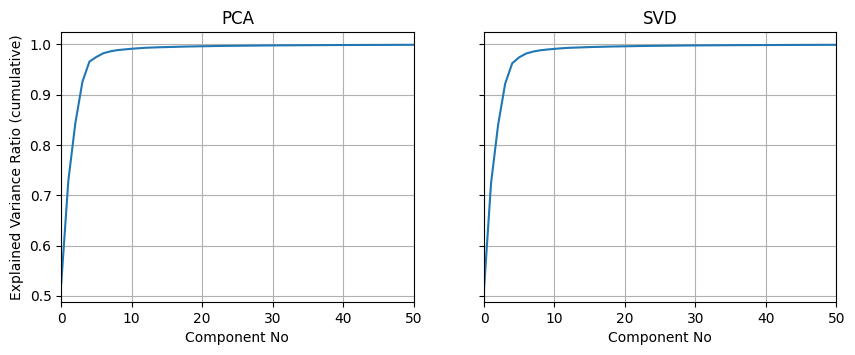

In [267]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

ax1.plot(pd.Series(pca_object.explained_variance_ratio_).cumsum())
ax1.grid()
ax1.set_xlim(0,50)
ax1.set_title('PCA')

ax2.plot(pd.Series(svd_object.explained_variance_ratio_).cumsum())
ax2.grid()
ax2.set_xlim(0,50)
ax2.set_title('SVD')

ax1.set_ylabel('Explained Variance Ratio (cumulative)')
ax1.set_xlabel('Component No')
ax2.set_xlabel('Component No')
plt.show()